In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import cv2
import wandb
from wandb.keras import WandbCallBack
from tensorflow.keras import layers
import tensorflow_probabilities as tfp
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback,CSVLogger,LearningRateScheduler,EarlyStopping,ModelCheckpoint
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPool2D,Dropout,InputLayer,BatchNormalization,Input,Layer,Dropout,RandomFlip,RandomRotation,RandomZoom,RandomContrast,RandomTranslation,RandomHeight,RandomWidth,Resizing,Rescaling
from tensorflow.keras.losses import MeanSquaredError,MeanAbsoluteError,Huber,BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy,FalsePositives,FalseNegatives,TruePositives,TrueNegatives,Precision,Recall,AUC,RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizer import L2,L1
from tensorboard.plugins.hparams import api as hp
import albumentations as A
import sklearn
from sklearn.metrics import confusion_matrix,roc_curve
import seaborn as sns

# ***WANDB INSTALL LOGIN AND INITIALIZATION And configuration***

In [ ]:
!pip install wandb
wandb login

In [ ]:
#wandb.init(project="Malaria-Detection",entity="neuralearn")
import tensorflow as tf
import wandb
wandb.tensorboard.patch(root_logdir="./logs")
wandb.init(project="Malaria-Detection",entity="neuralearn")

# **save model input and hyperparameters**

In [ ]:
wandb.config(
    'learning_rate':0.001,
    "epochs":3,
    "batch_size"128,
    "DROPOUT_RATE":0.0,
    "IM_SIZE":224,
    "REGULARIZATION_RATE":0.0,
    "N_FILTERS":6,
    "KERNEL_SIZE":3,
    "N_STRIDES":1,
    "POOL_SIZE":2,
    "N_DENSE_1":128,
    "N_DENSE_2":32
)

In [ ]:
wandb.run

In [ ]:
dataset,dataset_info=tfds.load('malaria',with_info=True,as_supervised=True,shuffle_files=True,split=['train'])

In [ ]:
def splits(dataset,TRAIN_RATIO,VAL_RATIO,TEST_RATIO):
  DATASET_SIZE=len(list(dataset))

  train_dataset=dataset.take(int(TRAIN_RATIO*DATASET_SIZE))

  val_test_dataset=dataset.skip(int(TRAIN_RATIO*DATASET_SIZE))
  val_dataset=val_test_dataset.take(int(VAL_RATIO*DATASET_SIZE))

  test_dataset=val_test_dataset.skip(int(VAL_RATIO*DATASET_SIZE))

  return train_dataset,val_dataset,test_dataset


In [ ]:
TRAIN_RATIO=0.8
VAL_RATIO=0.1
TEST_RATIO=0.1
#dataset=tf.data.Dataset.range(10)
train_dataset,val_dataset,test_dataset=splits(dataset[0],TRAIN_RATIO,VAL_RATIO,TEST_RATIO)

print("Train:", list(train_dataset.take(1).as_numpy_iterator()))
print("Val:", list(val_dataset.take(1).as_numpy_iterator()))
print("Test:", list(test_dataset.take(1).as_numpy_iterator()))

Train: [(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8), np.int64(1))]
Val: [(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
  

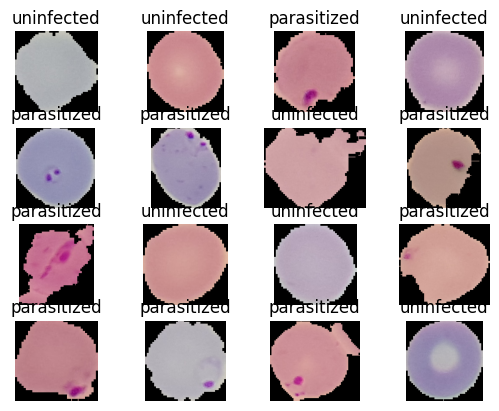

In [ ]:
for i, (image, label) in enumerate(train_dataset.take(16)):
  ax = plt.subplot(4, 4, i + 1)

  plt.imshow(image)
  plt.title(dataset_info.features['label'].int2str(label))
  plt.axis('off')


In [ ]:
# for i, (image, label) in enumerate(train_dataset.take(2)):
#   plt.subplot(1,4,2*i+1)
#   plt.imshow(image)
#   plt.subplot(1,4,2*i+2)
#   plt.imshow(tf.image.flip_left_right(image,0.3))
#   plt.title(dataset_info.features['label'].int2str(label))
#   plt.axis('off')

In [ ]:
dataset_info.features['label'].int2str(1)

'uninfected'

## ** DATA AUGMENTATION**

In [ ]:
def visualize(original,augmented):
  plt.subplot(1,2,1)
  plt.imshow(original)

  plt.subplot(1,2,2)
  plt.imshow(augmented)

In [ ]:
original_image,label=next(iter(train_dataset))
#augmented_image=tf.image.flip_left_right(original_image)#check tf.image and apply different techniques
#augmented_image=tf.image.adjust_brightness(original_image,delta=0.5)
#augmented_image=tf.image.random_saturation(original_image,lower=2,upper=12)
augmented_image=tf.image.central_crop(original_image,0.4)
visualize(original_image,augmented_image)

In [ ]:
IM_SIZE=224
@tf.function
def resize_rescale(image,label):
  return tf.image.resize(image,(IM_SIZE,IM_SIZE))/255.0,label

In [ ]:
tf.config.run_functions_eagerly(True)

# **TF.IMAGE AUGMENT**

In [ ]:
@tf.function
def augment(image,label):
  image,label=resize_rescale(image,label)
  image=tf.image.rot90(image,k=tf.random.uniform(shape=[],minval=0,maxval=2,dtype=tf.int32))
  #image=tf.image.adjust_saturation(image,saturation_factor=0.3)
  #image=tf.image.stateless_random_saturation(image,0.3,0.5)
  image=tf.image.flip_left_right(image)
  return image,label

In [ ]:
class Rotninety(Layer):
  def __init__(self):
    super().__init__()
  @tf.function
  def call(self,image):
    return tf.image.rot90(image,k=tf.random.uniform(shape=[],minval=0,maxval=2,dtype=tf.int32))


# **TF.KERAS.LAYER AUGMENT**

In [ ]:
resize_rescale_layer=tf.keras.Sequential([
    Resizing(IM_SIZE,IM_SIZE),
    Rescaling(1.0/255)
])

In [ ]:
# tf.keras.layer.RandomFlip(
#     mode=HORIZONTAL_AND_VERTICAL,seed=None,**kwargs
# )
# tf.keras.layer.RandomRotation(
#     factor,seed=None,fill_mode="reflect",interpolation="bilinear",fill_value=0.0,**kwargs
# )

augment_layers=tf.keras.Sequential([
    #RandomRotation(factor=(0.25,0.2501),),
    RotNinety()
    RandomFlip(mode='horizontal',),
])
@tf.function
def augment_layer(image,label):

  return augment_layers(resize_rescale_layer(image),training=True),label
#now in .map(add augment_layer instead of augment to use tf.keras.augment method)

SyntaxError: incomplete input (ipython-input-3434836503.py, line 12)

# TF.KERAS.LAYER RESIZING AND RESCALING

In [ ]:
test_dataset=test_dataset.map(resize_rescale_layer)

# **MIX UP DATA AUGMENTATION**

In [ ]:
train_dataset_1=train_dataset.shuffle(buffer_size=4096,).map(resize_rescale)
train_dataset_2=train_dataset.shuffle(buffer_size=4096,).map(resize_rescale)
mixed_dataset=tf.data.Dataset.zip((train_dataset_1,train_dataset_2))

In [ ]:
def mixup(train_dataset_1,train_dataset_2):
  (image_1,label_1),(image_2,label_2)=train_dataset_1,train_dataset_2



  lamda=tfp.distributions.Beta(0.2,0.2)
  lamda=lamda.sample(1)[0]


  image=lamda*image_1 + (1-lamda)*image_2
  label=lamda*tf.cast(label_1,dtype=tf.float32) + (1-lamda)*tf.cast(label_2,dtype=tf.float32)



  return image,label



In [ ]:
BATCH_SIZE=32
train_dataset=(
    mixed_dataset
    .shuffle(buffer_size=8,reshuffle_each_iteration=True)
    .map(mixup)
    .batch(1)
    .prefetch(tf.data.AUTOTUNE)
)


In [ ]:
# IM_SIZE=224
# image_1=cv2.resize(cv2.imread('cat.jpg'),(IM_SIZE,IM_SIZE))
# image_2=cv2.resize(cv2.imread('dog.jpg'),(IM_SIZE,IM_SIZE))
# print(image_1.shape,image_2.shape)

#   lamda=tfp.distributions.Beta(0.2,0.2)
#   lamda=lamda.sample(1)[0]


#   image=lamda*image_1 + (1-lamda)*image_2
#   label=lamda*label_1 + (1-lamda)*label_2

#   plt.imshow(image/255)

# **CUT MIX DATA AUGMENTATION**

In [ ]:
def box(lamda):
  r_x=tf.cast(tfp.distributions.Uniform(0,IM_SIZE).sample(1)[0],dtype=tf.int32)
  r_y=tf.cast(tfp.distributions.Uniform(0,IM_SIZE).sample(1)[0],dtype=tf.int32)

  r_w=tf.cast(IM_SIZE*tf.math.sqrt(1-lamda),dtype=tf.int32)
  r_h=tf.cast(IM_SIZE*tf.math.sqrt(1-lamda),dtype=tf.int32)

  r_x=tf.clip_by_value(r_x - r_w//2,0,IM_SIZE)
  r_y=tf.clip_by_value(r_y - r_h//2,0,IM_SIZE)

  x_b_r=tf.clip_by_value(r_x + r_w,0,IM_SIZE)
  y_b_r=tf.clip_by_value(r_y + r_h,0,IM_SIZE)

  r_w=x_b_r-r_x
  if(r_w==0):
    r_w=1

  r_h=y_b_r-r_y
  if(r_h==0):
    r_h=1

  return r_x,r_y,r_w,r_h

In [ ]:
def cutmix(train_dataset_1,train_dataset_2):
  (image_1,label_1),(image_2,label_2)=train_dataset_1,train_dataset_2

  lamda=tfp.distributions.Beta(0.2,0.2)
  lamda=lamda.sample(1)[0]

  r_y,r_x,r_w,r_h=box(lamda)

  crop_2=tf.image.crop_to_bounding_box(image,r_y,r_x,r_w,r_h)
  pad_2=tf.image.pad_to_bounding_box(crop_2,r_y,r_x,IM_SIZE,IM_SIZE)

  crop_1=tf.image.crop_to_bounding_box(image_1,r_y,r_x,r_w,r_h)
  pad_1=tf.image.pad_to_boundind_box(crop_1,r_y,r_x,IM_SIZE,IM_SIZE)

  image=image_1 - pad_1 + pad_2
  lamda=tf.cast(1 - (r_w*r_h)/(IM_SIZE*IM_SIZE),dtype=tf.float32)
  label=lamda*tf.cast(label_1,dtype=tf.float32) + (1-lamda)*tf.cast(label_2,dtype=tf.float32)

  return image,label


In [ ]:
original_image,label=next(iter(train_dataset))
plt.imshow(original_image[0])

In [ ]:
plt.figure(figsize=(16,8))

plt.subplot(1,7,1)
image_1=cv2.resize(cv2.imread('cat.jpg'),(IM_SIZE,IM_SIZE))
plt.imshow(image_1)


plt.subplot(1,7,2)
image_2=cv2.resize(cv2.imread('dog.jpg'),(IM_SIZE,IM_SIZE))
plt.imshow(image_2)

plt.subplot(1,7,3)
crop_image=tf.image.crop_to_bounding_box(image_1,20,15,100,98)
plt.imshow(crop)


plt.subplot(1,7,4)
image_4=tf.image.pad_to_bounding_box(crop,20,100,IM_SIZE,IM_SIZE)
plt.imshow(image_4)

plt.subplot(1,7,5)
image_4=tf.image.pad_to_bounding_box(crop,20,100,IM_SIZE,IM_SIZE)
plt.imshow(image4 + image_1)

plt.subplot(1,7,6)
crop_cat=tf.image.crop_to_bounding_box(image_1,20,15,100,98)
plt.imshow(crop_cat)

plt.subplot(1,7,7)
image_5=tf.image.pad_to_bounding_box(crop_cat,20,100,IM_SIZE,IM_SIZE)
plt.imshow(image_1 - image_5 + image_4)


# **DATA AUGMENTATION WITH ALBUMINATION**

In [ ]:
!pip install -U git+https://github.com/albu/albumentations --no-chache-dir

In [ ]:
transfroms=A.compose(
    [
        A.resize(IM_SIZE,IM_SIZE),
        A.OneOf([A.HorizontalFlip(),
        A.VerticalFlip(),],p=0.3),
        A.RandomRotate90(),
        A.RandomGridShuffle(),
        A.RandomBrightnessContrast(brightness_limit=0.2,
                                 contrast_limit=0.2,
                                 brightness_by_max=True,
                                 always_apply=False,
                                 p=0.5),
        A.cutout(num_holes=8,max_h_size=8,max_w_size=8,fill_value=0,always_apply=False,p=0.5)
        A.Sharpen(alpha(0.2,0.5),lightness=(0.5,1.0),always_apply=False,p=0.5)
    ]
)

In [ ]:
def aug_albument(image):
  data={"image":image}
  image=transfrom(**data)
  image=image["image"]
  image=tf.cast(image/255,tf.float32)
  return image

In [ ]:
def process_data(image,label):
  aug_img=tf.numpy_function(func=aug_albument,inp=[image],Tout=tf.float32)
  return aug_img,label

In [ ]:
train_dataset=(
    train_dataset
    .shuffle(buffer_size=8,reshuffle_each_iteration=True)
    .map(process_data )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
im,_=next(iter(train_dataset))
plt.imshow(im[0])

In [ ]:
plt.figure(figsize=(10,10))
for i in range(1,32):
  plt.subplot(8,4,i)
  plt.imshow(im[i])


In [ ]:
for image,label in train_dataset.take(1):
  print(image,label)

tf.Tensor(
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]], shape=(224, 224, 3), dtype=float32) tf.Tensor(1, shape=(), dtype=int64)


In [ ]:
BATCH_SIZE=32
train_dataset=(
    train_dataset
    .shuffle(buffer_size=8,reshuffle_each_iteration=True)
    .map(augment)
    .batch(1)
    .prefetch(tf.data.AUTOTUNE)
)


In [ ]:

val_dataset=(val_dataset
             .shuffle(buffer_size=8,reshuffle_each_iteration=True)
             .map(resize_rescale_layer)
             .batch(1)
             .prefetch(tf.data.AUTOTUNE)
             )

# **HYPERPARAMETER TUNINING WITH WANDB**

In [ ]:
 sweep_config={
     "name":"Malaria-Prediction-Sweep",
     "method":"random",
     "metric":{
         "name":"accuracy",
         "goal":"maximize"
     },
     "parameters":{
         "N_DENSE_1":{
             "values":[16,32,64,128]
         },
         "N_DENSE_2":{
             "values":[16,32,64,128]
         },
         "DROPOUT_RATE":{
             "min":0.1,
             "max":0.4
         },
         "REGULARIZATION_RATE":{
             "distribution":"uniform",
             "min":0.001,
             "max":0.1
         },
         "LEARNING_RATE":{
             "distribution":"uniform"
             "min":1e-4,
             "max":1e-2
         }
     }
 }
sweep_id=wandb.sweep(sweep_config)

In [ ]:
IM_SIZE=224
def model_tune(config):
  lenet_model=tf.keras.Sequential([
      InputLayer(input_shape=(config.IM_SIZE,config.IM_SIZE,3)),
      resize_rescale_layer,
      augment_layer,
      Conv2D(filters=config.N_FILTERS,kernel_size=config.N_KERNEL_SIZE,strides=config.N_STRIDES,padding='valid',activation='relu',kernel_regularizer=L2(config.REGULARIZATION_RATE)),
      BatchNormalization(),
      MaxPool2D(pool_size=config.POOL_SIZE,strides=config.N_STRIDES),
      Dropout(rate=hparams['HP_DROPOUT'])
      Conv2D(filters=config.N_FILTERS,kernel_size=config.N_KERNEL_SIZE,strides=config.N_STRIDES,padding='valid',activation='relu',kernel_regularizer=L2(config.REGULARIZATION_RATE)),
      BatchNormalization(),
      MaxPool2D(pool_size=config.POOL_SIZE,strides=config.N_STRIDES),
      Flatten(),
      Dense(config.N_DENSE_1,activation='relu',kernel_regularizer=L2(config.REGULARIZATION_RATE)),
      BatchNormalization(),
      Dropout(rate=config.DROPOUT_RATE)
      Dense(config.N_DENSE_1,activation='relu',kernel_regularizer=L2(config.REGULARIZATION_RATE)),
      BatchNormalization(),
      Dense(1,activation='sigmoid')

  ])

  return lenet_model

In [ ]:
CONFIGURATION=(
    'learning_rate':0.001,
    "epochs":3,
    "batch_size"128,
    "DROPOUT_RATE":0.0,
    "IM_SIZE":224,
    "REGULARIZATION_RATE":0.0,
    "N_FILTERS":6,
    "KERNEL_SIZE":3,
    "N_STRIDES":1,
    "POOL_SIZE":2,
    "N_DENSE_1":128,
    "N_DENSE_2":32
)

In [ ]:
def train():
  with wandb.init(project="Malaria-Detection",entity="nueralearn",config=CONFIGURATION) as run:
    config=wandb.config
    model=model_tune(config)
    model.compile(optimizer=Adam(
        learning_rate=config.LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=['accuracy']
    )
    model.fit(val_dataset,epochs=confog.N_EPOCHS,callback=[WandbCallback()])
count=5#number of run to execute
wandb.agent(sweep_id,function=train,count=count)

# **Hyperparameter tunining**

In [ ]:
IM_SIZE=224
def model_tune(hparams):
  lenet_model=tf.keras.Sequential([
      InputLayer(input_shape=(IM_SIZE,IM_SIZE,3)),
      resize_rescale_layer,
      augment_layer,
      Conv2D(filters=6,kernel_size=3,strides=1,padding='valid',activation='relu',kernel_regularizer=L2(hparams['HP_REGULARIZATION_RATE'])),
      BatchNormalization(),
      MaxPool2D(pool_size=2,strides=2),
      Dropout(rate=hparams['HP_DROPOUT'])
      Conv2D(filters=16,kernel_size=3,strides=1,padding='valid',activation='relu',kernel_regularizer=L2(params['HP_REGULARIZATION_RATE'])),
      BatchNormalization(),
      MaxPool2D(pool_size=2,strides=2),
      Flatten(),
      Dense(hparams['HP_NUM_UNITS_1'],activation='relu',kernel_regularizer=L2(params['HP_REGULARIZATION_RATE'])),
      BatchNormalization(),
      Dropout(rate=hparams['HP_DROPOUT'])
      Dense(hparams['HP_NUM_UNITS_2'],activation='relu',kernel_regularizer=L2(params['HP_REGULARIZATION_RATE'])),
      BatchNormalization(),
      Dense(1,activation='sigmoid')

  ])
  lenet_model.compile(optimizer=Adam(lr=hparams[HP_LEARNING_RATE]),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
  lenet_model.fit(val_dataset,epochs=1)
  _,accuracy=lenet_model.evaluate(val_dataset)
  return accuracy


In [ ]:
HP_NUM_UNITS_1=hp.HParam('num_units_1',hp.Discrete([16,32,64,128]))
HP_NUM_UNITS_2=hp.HParam('num_units_2',hp.Discrete([16,32,64,128])
HP_DROPOUT=hp.HParam('dropout',hp.Discrete(0.1,0.2,0.3,0.4,0.5))
HP_REGULARIZATION_RATE=hp.HParam('ragularization_rate',hp.Discrete([0.001,0.01,0.1]))
HP_LEARNING_RATE=hp.HParam('learning_rate',hp.Discrete([1e-3,1e-4]))

In [ ]:
run_number=0
for num_units_1 in HP_NUM_UNITS_1.domain.values:
  for num_units_2 in HP_NUM_UNITS_2.domain.values:
    for dropout_rate in HP_DROPOUT.domain.values:
      for regularization_rate in HP_REGULARIZATION_RATE.domain.values:
        for learning_rate in HP_LEARNING_RATE.domain.values:
          hparams={
              HP_NUM_UNITS_1:num_units_1,
              HP_NUM_UNITS_2:num_units_2,
              HP_DROPOUT:dropout_rate,
              HP_REGULARIZATION_RATE:regularization_rate,
              HP_LEARNING_RATE=learning_rate
          }
          file_writer=tf.summary_create_filewriter('logs/'+ str(run_number))
          with file_writer.as_default():
            hp.params(hparams)
            accuracy=model_tune(hparams)
           tf.summary.scalar('accuracy',accuracy,step=0)
          print("For the run {},hparam num_units_1:{}, num_units_2:{},dropout:{},regularization_rate:{},learning_rate:{}",hparams[HP_NUM_UNITS_1],hparams[HP_NUM_UNITS_2],hparam[HP_DROPOUT],hparams=[HP_REGULARIZATION_RATE],hparams=[HP_LEARNING_RATE])
          run_number+=1

# **WANDB DATA VERSIONING**

## **DATA VERSIONING**

In [ ]:
dataset,dataset_info=tfds.load('malaria',with_info=True,as_supervised=True,shuffle_files=True,split=['train'])
print(dataset)

In [ ]:
k=0
for data in dataset[0]:
  with open('dataset/malaria_dataset_'+str[k]+'.npz',mode='wb') as file:
    np.savez(file,data)
  k+=1
  if(k%1000==0):
    print(k)



In [ ]:
def load_original_data():
  with wandb.init(project="Malaria-Detection",entity="neuralearn") as run:
    original_data=wandb.artifact(
        name = "new_dataset",
        type="raw_data",
        description = "The Malaria dataset contains a total of 27,558 cell images with equal instances of parasitized and uninfected cells from the thin blood smear slide images of segmented cells.",
        metadata = {"source": "TFDS",
                    "homepage": "https://lhncbc.nlm.nih.gov/publication/pub9932",
                    "source_code": "tfds.image_classification.Malaria",
                    "version": "1.0.0",
                    "download_size": "337.08 MiB",
                    }
    )
    original_data.add_dir('dataset/')
    run.log_artifact(original_data)

In [ ]:
load_original_data()

 **Data Preprocessing**

In [ ]:
with wandb.init(project='Malaria-Detection',entity='neuralearn') as run:
  artifact=run.use_artifact('neuralearn/Malaria-Detection/new_dataset:v1',type='raw_data')
  artifact_dir=artifact.download()

In [ ]:
IM_SIZE=224
def resize_rescale(image):
  return tf.image.resize(image,(IM_SIZE,IM_SIZE))/255.0

In [ ]:
def preprocess_data():
  with wandb.init(project='Malaria-Detection',entity='neuralearn') as run:
  artifact=run.use_artifact('neuralearn/Malaria-Detection/new_dataset:v1',type='raw_data')
  artifact_dir=artifact.download()

  preprocessed_data=wandb.artifact(
      name="preprocessed_data",
      type="preprocessed_data",
      description="Apreprocessed version of malaria dataset"
  )
  artifact_directory="artifacts/new_dataset:v1/"

  dataset_x=[]
  dataset_y=[]
  for f in os.listdir(artifact_directory)[:1000]:
    with open(artifact_directory + f,'rb') as file:
      npz_array=np.load(file,allow_pickle=True)
      x,y=npz_array.f.arr_0
      dataset_x.append(resize_rescale(x))
      dataset_y.append(y)
  with preprocessed_data.new_file("prep_dataset.npz",mode="wb") as file:
    np.savez(file,[dataset_x,dataset_y])
  run.log_artifact(preprocessed_data)


In [ ]:
preprocess_data()

Data **Splitting**

In [ ]:
run=wandb.init()
artifact=run.use_artifact('neuralearn/Malaria_Detection/preprocessed_dataset2:v2',type="preprocessed_data")
artifact_dir=artifact.download()

In [ ]:
def split_data():
   with wandb.init(project="Malaria-Detection", entity="neuralearn") as run:

    artifact = run.use_artifact('neuralearn/Malaria-Detection/preprocessed_dataset:v2', type='preprocessed_data')
    artifact_dir = artifact.download()

    train_data=wandb.Artifact(
        name="train_dataset",
        type="preprocessed_data",
        description="training dataset"
    )
    val_data=wandb.Artifact(
        name="val_dataset",
        type="preprocessed_data",
        description="validation dataset"
    )
    test_data=wandb.Artifact(
        name="test_dataset",
        type="preprocessed_data",
        description="test dataset"
    )

    artifact_file="artifacts/preprocessed_dataset:v2/prep_dataset.npz"
    with open(artifact_file,'rb') as file:
      npz_arr=np.load(file,allow_pickle=True)
      arr=npz_arr.f.arr_0

    train_split=0.8
    val_split=0.1
    test_split=0.1

    data_len=len(arr[0])

    train_arr = [arr[0][0:int(train_split*data_len)], arr[1][0:int(train_split*data_len)]]
    val_arr = [arr[0][int(train_split*data_len):int((train_split+val_split)*data_len)], arr[1][int(train_split*data_len):int((train_split+val_split)*data_len)] ]
    test_arr = [arr[0][int((train_split+val_split)*data_len):], arr[1][int((train_split+val_split)*data_len):] ]

    with train_data.new_file("train_dataset.npz",mode="wb") as file:
      np.savez(file,train_arr)

    with val_data.new_file("val_dataset.npz",mode="wb") as file:
      np.savez(file,val_arr)

    with test_data.new_file("test_dataset.npz",mode="wb") as file:
      np.savez(file,test_arr)


    run.log_artifact(train_data)
    run.log_artifact(val_data)
    run.log_artifact(test_data)






In [ ]:
split_data()

 **Data Augmentation**

In [ ]:
def augment(image):
  image=tf.image.rot90(image)
  image=tf.image.flip_left_right(image)
  return image


In [ ]:
/contertifant/acts/train_dataset:v0/train_dataset.npz

In [ ]:
wandb.finish()

In [ ]:
def augment_data():
  with wandb.init(project="Malaria-Detection", entity="neuralearn") as run:

    artifact = run.use_artifact('neuralearn/Malaria-Detection/train_dataset:v0', type='preprocessed_data')
    artifact_dir = artifact.download()

    augmented_data = wandb.Artifact(
        name = "Augmented_dataset",
        type="preprocessed_data",
        description = "An Augmented version of the Malaria train dataset",
    )

    artifact_file = "artifacts/train_dataset:v0/train_dataset.npz"

    dataset_x=[]
    with open(artifact_file,'rb') as file:
      npz_array=np.load(file,allow_pickle=True)
      arr=npz_array.f.arr_0

      for im in arr[0]:
        dataset_x.append(augment(im))
        dataset_y=arr[1]

    with augment_data.new_file("aug_dataset.npz",mode="wb") as file:
      np.savez(file,[dataset_x,dataset_y])
    run.log_artifact(augment_data)

In [ ]:
augment_data()

# **WANDB MODEL VERSIONING**

In [ ]:
def log_model():
  with wandb.init(project="Malaria-Detection", entity="neuralearn") as run:



    untrained_model = wandb.Artifact(
        name = "Untrained_model",
        type="model",
        description = "The initial version of our lenet model",
        metadata=CONFIGURATION
    )
    filename='lenet.h5'
    lenet_model.save(filename)

    untrained_model.add_file(filename)
    wandb.save(filename)


    run.log_artifact(untrained_model)

In [ ]:
log_model()

In [ ]:
def train_and_log():
  with wandb.init(project="Malaria-Detection",entity="neuralearn") as run:
    artifact=run.use_artifact('neuralearn/Malaria-Detection/Augmented_dataset:v0',type='preprocessed_data')
    artifact_dir=artifact.download()

    trained_sequential_model=wandb.Artifact(
        name="Train_Sequential_Model",
        type="model",
        description="A trained version of our model",
        metadata=CONFIGURATION
    )
    artifact_file = "artifacts/train_dataset:v0/train_dataset.npz"
    dataset_x=[]
    with open(artifact_file,'rb') as file:
      npz_array=np.load(file,allow_pickle=True)
      arr=npz_array.f.arr_0

      for im in arr[0]:
        dataset_x.append(augment(im))
        dataset_y=arr[1]
  d_x=tf.convert_to_tensor(dataset_x,dtype=tf.float32)
  d_y=tf.convert_to_tensor(dataset_y,dtype=tf.float32)
  d=tf.data.Dataset.from_tensor_slices((d_x,d_y))
  train_d=(
      d,
      .shuffle(buffer_size=1024,reshuffle_each_iteration=True)

      .batch(BATCH_SIZE)
      .prefetch(tf.data.AUTOTUNE)
  )


  artifact=run.use_artifact('neuralearn/Malaria-Detection/Untrained_model:v0',type='preprocessed_data')
    artifact_dir=artifact.download()

  artifact_file="artifacts/Untrained_model:v0/lenet.h5"
  lenet_model-tf.keras.load_model(artifact_file)


  metrics=[TruePositives(name="tp"),FalsePositives(name="fp"),FalseNegatives("fn"),TrueNegatives(name="tn"),
         BinaryAccuracy(name="accuracy"),Precision(name="precision"),Recall(name="recall"),AUC(name="auc")]
  lenet_model.compile(optimizer=Adam(learning_rate=0.01),
              loss=BinaryCrossentropy(),
              #metrics=RootMeanSquaredError()
              metrics=metrics,
              run_eagerly=True
              )
  lenet_model.fit(
      train_d,
      epochs=3,
      verbose=1,
      callbacks=[WandbCallback()]
  )
  filename='lenet_trained.h5'
  lenet_model.save(filename)
  trained_sequential_model.add_file(filename)
  wandb.save(filename)
  run.log_artifact(trained_sequential_model)



# Model Creation

In [ ]:
configuration=wandb.config
IM_SIZE=configuration['IM_SIZE']
dropout_rate=configuration['DROPOUT_RATE']
regularization_rate=configuration['REGULARIZATION_RATE']
N_FILTERS=configuration['N_FILTERS']
KERNEL_SIZE=configuration['KERNEL_SIZE']
N_STRIDES=configuration['N_STRIDES']
POOL_SIZE=configuration['POOL_SIZE']
dropout_rate=0.3
regularization_rate=0.01
lenet_model=tf.keras.Sequential([
    InputLayer(input_shape=(None,None,3)),
    resize_rescale_layer,
    augment_layer,
    Conv2D(filters=6,kernel_size=3,strides=1,padding='valid',activation='relu',kernel_regularizer=L2(0.01)),
    BatchNormalization(),
    MaxPool2D(pool_size=2,strides=2),
    Dropout(rate=dropout_rate)
    Conv2D(filters=16,kernel_size=3,strides=1,padding='valid',activation='relu',kernel_regularizer=L2(0.01)),
    BatchNormalization(),
    MaxPool2D(pool_size=2,strides=2),
    Flatten(),
    Dense(units=100,activation='relu',kernel_regularizer=L2(0.01)),
    BatchNormalization(),
    Dropout(rate=dropout_rate)
    Dense(units=10,activation='relu',kernel_regularizer=L2(0.01)),
    BatchNormalization(),
    Dense(units=1,activation='sigmoid')

])
lenet_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

In [ ]:
feature_extractor_sequential_model=tf.keras.Sequential([
    InputLayer(input_shape=(IM_SIZE,IM_SIZE,3)),
    Conv2D(filters=6,kernel_size=3,strides=1,padding='valid',activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=2,strides=2),
    Conv2D(filters=16,kernel_size=3,strides=1,padding='valid',activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=2,strides=2),
    Flatten(),

])
feature_extractor_seq_model.summary()

In [ ]:
func_input=Input(shape=(IM_SIZE,IM_SIZE,3), name="Input Image")
x=feature_extractor_seq_model(func_input)
x=Flatten()(x),
x=Dense(units=100,activation='relu')(x),
x=BatchNormalization()(x),
x=Dense(units=10,activation='relu')(x),
x=BatchNormalization()(x),
func_output=Dense(units=1,activation='sigmoid')(x)

lenet_model_func=Model(func_input,func_output,name="Lenet_Model")
lenet_model_func.summary()

# FUNCTIONAL **API**

In [ ]:
func_input=Input(shape=(IM_SIZE,IM_SIZE,3), name="Input Image")
x=Conv2D(filters=6,kernel_size=3,strides=1,padding='valid',activation='relu')(func_input),
x=BatchNormalization()(x),
x=MaxPool2D(pool_size=2,strides=2)(x),
x=Conv2D(filters=16,kernel_size=3,strides=1,padding='valid',activation='relu')(x),
x=BatchNormalization()(x),
func_output=MaxPool2D(pool_size=2,strides=2)(x),

feature_extractor_model=Model(func_input,output,name="Feature_Extractor")
feature_extractor_model.summary()

In [ ]:
func_input=Input(shape=(IM_SIZE,IM_SIZE,3), name="Input Image")
x=feature_extractor_model(func_input)
x=Flatten()(x),
x=Dense(units=100,activation='relu')(x),
x=BatchNormalization()(x),
x=Dense(units=10,activation='relu')(x),
x=BatchNormalization()(x),
func_output=Dense(units=1,activation='sigmoid')(x)

lenet_model_func=Model(func_input,func_output,name="Lenet_Model")
lenet_model_func.summary()

# **Model Subclassing**

In [ ]:
class featureExtractor(Layer):
  def __init__(self,filters,kernel_size,strides,padding,activation,pool_size):
    super(featureExtractor,self).__init__()

    self.conv1=Conv2D(filters=filters,kernel_size=kernel_size,strides=strides,padding=padding,activation=activation)
    self.batch_1=BatchNormalization()
    self.pool_1=MaxPool2D(pool_size=pool_size,strides=2*strides)
    self.conv2=Conv2D(filters=filters*2,kernel_size=kernel_size,strides=strides,padding=padding,activation=activation)
    self.batch_2=BatchNormalization()
    self.pool_2=MaxPool2D(pool_size=pool_size,strides=2*strides)

    def call(self,x):
      x=self.conv1(x)
      x=self.batch_1(x)
      x=self.pool_1(x)
      x=self.conv2(x)
      x=self.batch_2(x)
      x=self.pool_2(x)
      return x

Featured_subclassed=FeatureExtractor(8,3,1,"valid","relu",2)



In [ ]:
func_input=Input(shape=(IM_SIZE,IM_SIZE,3), name="Input Image")
x=feature_subclassed(func_input)
x=Flatten()(x),
x=Dense(units=100,activation='relu')(x),
x=BatchNormalization()(x),
x=Dense(units=10,activation='relu')(x),
x=BatchNormalization()(x),
func_output=Dense(units=1,activation='sigmoid')(x)

lenet_model_func=Model(func_input,func_output,name="Lenet_Model")
lenet_model_func.summary()

In [ ]:
class Lenet(Model):
  def __init__(self,filters,kernel_size,strides,padding,activation,pool_size):
    super(LenetModel,self).__init__()

    self.feature_extractor=FeatureExtractor(8,3,1,"valid","relu",2)
    self.flatten=Flatten()
    self.dense_1=Dense(100,activation='relu')
    self.batch_1=BatchNormalization()

    self.dense_2=Dense(10,activation='relu')
    self.batch_2=BatchNormalization()

    self.dense_3=Dense(1,activation='sigmoid')


    def call(self,x):
      x=self.feature_extractor(x)
      x=self.flatten(x)

      x=self.dense_1(x)
      x=self.batch_1(x)

      x=self.dense_2(x)
      x=self.batch_2(x)

      x=self.dense_3(x)
      return x
Lenet_sub_classed=LenetModel()
lenet_sub_classed(tf.zeros([1,224,224,3]))
lenet_sub_classed.summary()

In [ ]:
y_true=[0,]
y_pred=[1.2,]
bce=tf.keras.losses.BinaryCrossentropy()#use from_logits=True to make the values between 0-1
bce(y_true,y_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=15.942384719848633>

# **CUSTOM LAYER**

In [ ]:
class NeuralLearnDense(Layer):
  def __init__(self,output_units,activation):
    super(NeuralLearnDense,self).__init__()
    self.output_units=output_units
    self.activation=activation
  def build(self,input_features_shape):
    self.w=self.add_weight(shape=(input_feature_shape[-1],self.output_units),initializer="random_normal",trainable=True)
    self.b=self.add_weight(shape=(self.output_units,),initializer="random_normal",trainable=True)

  def call(self,input_features):
    pre_output=tf.matmul(input_features,self.w)+self.b
    if(self.activation=="relu"):
      return tf.nn.relu(pre_output)
    elif(self.activation=="sigmoid"):
      return tf.math.sigmoid(pre_output)
    else:
      return pre_output


In [ ]:
IM_SIZE=224
lenet_custom_model=tf.keras.Sequential([
    InputLayer(input_shape=(IM_SIZE,IM_SIZE,3)),
    Conv2D(filters=6,kernel_size=3,strides=1,padding='valid',activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=2,strides=2),
    Conv2D(filters=16,kernel_size=3,strides=1,padding='valid',activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=2,strides=2),
    Flatten(),
    NeuralLearnDense(units=100,activation='relu'),
    BatchNormalization(),
    NeuralLearnDense(units=10,activation='relu'),
    BatchNormalization(),
    NeuralLearnDense(units=1,activation='sigmoid')

])
lenet_custom_model.summary()

# **CALLBACKS**

In [ ]:
class LossCallback(Callback):
  def on_epoch_end(self,epoch,logs):
    print("\nFor Epoch Numbers {} the model has a loss of {}".format(epoch+1,logs["loss"]))
  def on_batch_end(self,batch,logs):
    print("\nFor Batch Numbers {} the model has a loss of {}".format(batch+1,logs)

# **CSV LOGGER**

In [ ]:
csv_callback=CSVLogger(
    filename="logs.csv",
    separator=",",
    append=False
)

# **EARLYSTOPPING**

In [ ]:
es_callback=EarlyStopping(
    monitor="val_loss",min_delta=0,patience=3,verbose=1,mode='auto',baseline=None,restore_best_weights=False
)

# **TENSOR BOARD CALLBACK**

In [ ]:
!pip install -U tensorboard_plugin_profile

In [ ]:
!rm -rf ./logs/

In [ ]:
CURRENT_TIME=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
METRIC_DIR='./log/'+CURRENT_TIME+'/metrics'
train_writer=tf.summary.create_file_writer(METRIC_DIR)

In [ ]:
LOG_DIR='./logs/'+ CURRENT_TIME
tensorboard_callback=tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR,profile_batch='100,132')

# **Display image in tensor board callback**

In [ ]:
class LogImagesCallback(Callback):
  def on_epoch_end(self,epoch,logs):
    labels=[]
    inp=[]

    for x,y in val_dataset.as_numpy_iterator():
      labels.append(y)
      inp.append(x)
    labels=np.array([i[0] for i in labels])
    predicted=lenet_model.predict(np.array(inp)[:,0,...])

    threshold(0.5)

    cm=confusion_matrix(labels,predicted>threshold)

    plt.figure(figsize=(8,8))
    sns.heatmap(cm,annot=True)
    plt.title("Confusion Matrix -{}.".format(threshold))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.axis('off')

    buffer=io.BytesIO()
    plt.savefig(buffer,format='png')
    image=tf.image.decode_png(buffer.getvalue(),channels=3)


    CURRENT_TIME=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    IMAGE_DIR='./log/'+CURRENT_TIME+'/images'
    image_writer=tf.summary.create_file_writer(IMAGE_DIR)

    with image_writer.as_default():
      tf.summary.image("Training data",image,step=epoch)


# **WANDB CALLBACK**

In [ ]:
class LogImagesCallbackWandBPlot(Callback):
  def on_epoch_end(self,epoch,logs):
    labels=[]
    inp=[]

    for x,y in val_dataset.as_numpy_iterator():
      labels.append(y)
      inp.append(x)
    labels=np.array([i[0] for i in labels])
    predicted=lenet_model.predict(np.array(inp)[:,0,...])

    print("labels",labels,labels.dtype)
    print("predicted",predicted,predicted.dtype)

    pred=[]
    for i in range(len(predicted)):
      if (predicted[i][0]<0.5):
        pred.append([1,0])
      else:
        pred.append([0,1])
    pred=np.array(pred)



    # wandb.log({"confusion-matrix":wandb.plot.confusion_matrix(probs=pred,
    #                                                           y_true=ground_truth
    #                                                           ,class_names=["parasitized","uninfected"])})
    wandb.log({
        "ROC CURVE":wandb.plot.roc_curve(
            y_true=labels,
            y_probas=pred,
            labels=["parasitized","uninfected"]
        )
    })
    wandb.log({
        "loss":logs["loss"]
    })




NameError: name 'Callback' is not defined

In [ ]:
class LogImagesCallbackWandb(Callback):
  def on_epoch_end(self,epoch,logs):
    labels=[]
    inp=[]

    for x,y in val_dataset.as_numpy_iterator():
      labels.append(y)
      inp.append(x)
    labels=np.array([i[0] for i in labels])
    predicted=lenet_model.predict(np.array(inp)[:,0,...])

    threshold(0.5)

    cm=confusion_matrix(labels,predicted>threshold)

    plt.figure(figsize=(8,8))
    sns.heatmap(cm,annot=True)
    plt.title("Confusion Matrix -{}.".format(threshold))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.axis('off')

    buffer=io.BytesIO()
    plt.savefig(buffer,format='png')
    image_array=tf.image.decode_png(buffer.getvalue(),channels=3)

    images=wandb.Image(image_array,caption="Confusion matrix for epoch: {}".format(epoch))
    wandb.log({"Confusion matrix":images})



# **LEARNING RATE SCHEDULER**

In [ ]:
def scheduler(epoch,lr):
  if epoch<=3:
    learning_rate=lr;

  else:
    learning_rate=lr*tf.math.exp(-0.1)
    learning_rate=learning_rate.numpy()
  with train_writer.as_default():
    tf.summary.scalar('Learning rate',data=learning_rate,step=epoch)
  return learning_rate
scheduler_callback=LearningRateScheduler(scheduler,verbose=1)

# **MODEL CHECK POINTING**

In [ ]:
checkpoint_callback=ModelCheckpoint(
    "checkpoints/",monitor="val_loss",verbose=0,save_best_only=False,save_weights_only=False,mode="auto",save_freq="epoch",options=None,**kwargs
)

# **REDUCE LEARNING RATE ON PLATEAU**

In [ ]:
plateau_callback=ReduceLROnPlateau(
    monitor="val_accuracy",factor=0.1,patience=2,verbose=1
)

In [ ]:
metrics=[TruePositives(name="tp"),FalsePositives(name="fp"),FalseNegatives("fn"),TrueNegatives(name="tn"),
         BinaryAccuracy(name="accuracy"),Precision(name="precision"),Recall(name="recall"),AUC(name="auc")]
LABELS=['Parasitized','Uninfected']

# **Custom Metric Class**

In [ ]:
class CustomAccuracy(tf.keras.metrics.Metric):
  def __init__(self,name="Custom_Accuracy",Factor=1):
    super(CustomAccuracy,self).__init__()
    self.Factor=Factor
    self.accuracy=self.add_weight(name=name,initializer="zeros")

  def update_state(self,y_true,y_pred,sample_weight=None):
    output=binary_accuracy(tf.cast(y_true,dtype=tf.float32),y_pred)*Factor
    self.accuracy.assign(tf.math.count_nonzero(output,dtype=tf.float32)/tf.cast(len(output),dtype=tf.float32)

  def result(self):
    return self.accuracy

  def reset_states(self):
    self.accuracy.assign(0.)


# **Custom Metric Method(Without Parameter)**

In [ ]:
def custom_accuracy(y_true,y_pred):
  return binary_accuracy(y_true,y_pred)

# **Custom Metric Method(With Parameter)**

In [ ]:
def custom_accuracy(FACTOR):
  def metric(y_true,y_pred):
    return binary_accuracy(y_true,y_pred)*FACTOR
  return metric

# **Custom Loss Class**

In [ ]:
 FACTOR=1
 class CustomBCE(tf.keras.losses.loss):
  def __init__(self,FACTOR):
    super(CustomBCE,self).__init__()
    self.FACTOR=FACTOR
  def call(self,y_true,y_pred):
    bce=BinaryCrossEntropy()
    return bce(y_true,y_pred)*self.FACTOR

# **Custom Loss Method(without Parameter)**

# **Custom Loss Method(With Parameter**

In [ ]:
FACTOR=1
def custom_bce(FACTOR):
  def loss(y_true,y_pred):
    bce=BinaryCrossEntropy()
    return bce(y_true,y_pred)*FACTOR
  return loss

In [ ]:
lenet_model.compile(optimizer=Adam(learning_rate=0.01),
              loss=BinaryCrossentropy(),
              #metrics=RootMeanSquaredError()
              metrics=metrics,
              run_eagerly=True
              )

In [ ]:
history=lenet_model.fit(train_dataset,validation_data=val_dataset,epochs=configuration["N_EPOCHS"],verbose=1
                        ,callback=[LogImagesCallbackWandB(),WandbCallback(
                            validation_data=val_dataset,
                            labels=LABELS,
                            data_type='image',
                        )])#callbacks=[tensorboard_callback,plateau_callback,checkpoint_callback,scheduler_callback,es_callback])

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.8096 - loss: 0.4029 - val_accuracy: 0.8813 - val_loss: 0.3428
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.9354 - loss: 0.1940 - val_accuracy: 0.9434 - val_loss: 0.1819
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.9489 - loss: 0.1658 - val_accuracy: 0.9372 - val_loss: 0.2440
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.9530 - loss: 0.1491 - val_accuracy: 0.9481 - val_loss: 0.1703
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9579 - loss: 0.1346 - val_accuracy: 0.9503 - val_loss: 0.1712
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.9625 - loss: 0.1190 - val_accuracy: 0.9292 - val_loss: 0.3561
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.9627 - loss: 0.1131 - val_accuracy: 0.9452 - val_loss: 0.1955
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.9679 - loss: 0.1054 - 

In [ ]:
wandb.finish()

# ***CUSTOM TRAINING LOOP***

In [ ]:
CURRENT_TIME=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
CUSTOM_TRAIN_DIR='./log/'+CURRENT_TIME+'/custom/train'
CUSTOM_VAL_DIR='./log/'+CURRENT_TIME+'/custom/val'
_custom_train_writer=tf.summary.create_file_writer(CUSTOM_TRAIN_DIR)
_custom_val_writer=tf.summary.create_file_writer(CUSTOM_VAL_DIR)

In [ ]:
OPTIMIZER=Adam(learning_rate=0.01)
METRIC=BinaryAccuracy()
METRIC_VAL=BinaryAccuracy()
EPOCHS=configuration["N_EPOCHS"]

In [ ]:
@tf.function
def training_block(x_batch,y_batch):
  with tf.GradientTape as recorder:
      y_pred=lenet_model(x_batch,training=True)
      loss=custom_bce(y_batch,y_pred)
  partial_derivatives=recorder.gradient(loss,model.trainable_weights)
  OPTIMIZER.apply_gradients(zip(partial_derivatives,model.trainable_weights))
  METRIC.update_state(y_batch,y_pred)
  return loss


In [ ]:
@tf.function
def validation_block(x_batch_val,y_batch_val):
  y_pred_val=lenet_model(x_batch_val,training=False)
  loss_val=custom_bce(y_batch_val,y_pred_val)
  METRIC_VAL.update_state(y_batch_val,y_pred_val)
  return loss_val


In [ ]:
def neuralearn(model,loss_function,METRIC,VAL_METRIC,OPTIMIZER,train_dataset,val_dataset,EPOCHS):
  for epoch in range(EPOCHS):
  print("Training start for epoch number {}".format(epoch))
  for step,(x_batch,y_batch) in  enumerate(train_dataset):
    loss=training_block(x_batch,y_batch)


  print("Training Loss:",loss)
  print("The accuracy is: ",METRIC.result())
  with custom_train_writer.as_default():
   tf.summary.scalar('Training Loss',data=learning_rate,step=epoch)

  with custom_train_writer.as_default():
   tf.summary.scalar('Training Accuracy',data=METRIC.result(),step=epoch)
  METRIC.reset_states()

  for (x_batch_val,y_batch_val) in val_dataset:
    loss_val=validation_block(x_batch_val,y_batch_val)



  print("The validation loss",loss_val)
  print("The accuracy is: ",METRIC_VAL.result())
  with custom_val_writer.as_default():
   tf.summary.scalar('validation  Loss',data=loss_val,step=epoch)

  with custom_val_writer.as_default():
   tf.summary.scalar('Validation Accuracy',data=METRIC_VAL.result(),step=epoch)
  METRIC_VAL.reset_states()


In [ ]:
neuralearn(lenet_model,custom_bce,METRIC,VAL_METRIC,OPTIMIZER,train_dataset,val_dataset,EPOCHS)

In [ ]:
image=cv2.imread('cell.jpg')
print(image.shape)
image=tf.expand_dims(image,axis=0)
print(image.shape)
lenet_model.predict(image)

# **TENSORBOARD VISUALIZATION**

In [ ]:
%load_ext tensorboard

In [ ]:
tensorboard --logdir='./logs'

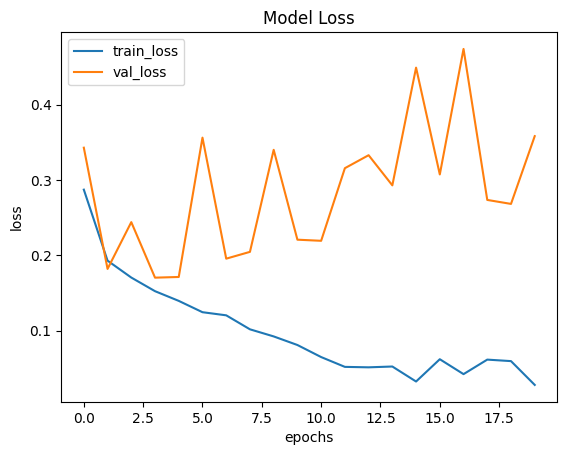

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(['train_loss','val_loss'])
plt.show()

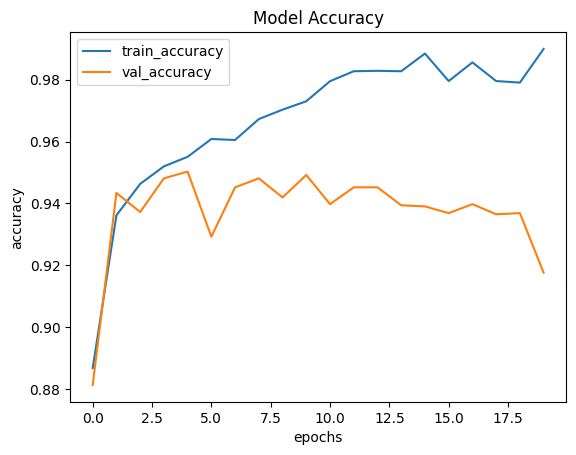

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train_accuracy','val_accuracy'])
plt.show()

# Model Evaluation and Testing

In [ ]:
test_dataset=test_dataset.batch(1)

In [ ]:
test_dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, None), dtype=tf.int64, name=None))>

In [ ]:
lenet_model.evaluate(test_dataset)

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

# **VISUALIZING CONFUSION MATRIX**

In [ ]:
labels=[]
inp=[]
for x,y in test_dataset.as_numpy_iterator():
  labels.append(y)#output
  inp.append(x)#input

In [ ]:
print(np.array(inp).shape)#(2757,1,224,224,3)
print(np.array(inp)[:,0,...].shape)#(2757,224,224,3)



In [ ]:
labels=np.array(i[0] for i in labels)
print(labels)

In [ ]:
predicted=lenet_model.predict(np.array(inp)[:,0,...])
print(predicted[:,0])

In [ ]:
threshold=0.5
cm=confusion_matrix(labels,predicted >threshold)
print(cm)
plt.figure(figsize=(8,8))
sns.heatmap(cm,annot=True)
plt.title("Confusion Matrix -{}.".format(threshold))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **ROC PLOT**

In [ ]:
fp,tp,thresholds=roc_curve(labels,predicted)
print(len(fp),len(tp),len(thresholds))
plt.plot(fp,tp)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc curve")
plt.grid()
skip=20
for i in range(0,len(thresholds),skip):
  plt.text(fp[i],tp[i],str(thresholds[i]))
plt.show()

In [ ]:
parasite_or_not(lenet_model.predict(test_dataset.take(1))[0][0])

In [ ]:
def parasite_or_not(x):
  if x<0.5:
    return str('P')
  else:
    return str('U')


In [ ]:
for i,(image,label) in enumerate(test_dataset.take(9)):
  ax=plt.subplot(3,3,i+1)
  plt.imshow(image[0])
  plt.title(str(parasite_or_not(label.numpy()[0]))) +":"+str(parasite_or_not(lenet_model.predict(image)[0][0]))
  plt.axis("off")